# Boron in Pressurized Water Reactors 

##### Cecilie1, Ceilie2, Marie, Kristian

Simulate with: 
- Bor as burnable poison (added to moderator)
- Gad as burnable poison (added to fuel)

Determine: 
- $k_{eff}$
- pitch 
- Depletion chains 
- Flux

reactor design: 
- fuel: U235-0.04, U238-0.95, O16-2.0, dens-10.5
- cladding: Zr-1.0
- coolant: H1-2.0, O16-1.0
- 17x17 lattice 
- 25 controlrods?

In [1]:
import os

import openmc
import openmc.model
import openmc.deplete


import numpy as np
import matplotlib.pyplot as plt
import tempfile

openmc.reset_auto_ids() #reset auto IDs to avoid conflicts with previous runs, probably not necessary (found that no material in gap caused the issue - but just to be safe) 
openmc.deplete.pool.USE_MULTIPROCESSING = True

In the following the different functions are created to build the model

In [2]:
def material(name, density, temperature=293.6,  nuclides=None, elements=None): #function to create materials for the reactor 
    mat = openmc.Material(name=name, temperature=temperature) #material
    mat.set_density('g/cm3', density) #density of the material
    if nuclides: #if there are nuclides, add them to the material
        for nuclide, fraction in nuclides.items():
            mat.add_nuclide(nuclide, fraction)
    if elements: #if there are elements, add them to the material
        for element, fraction in elements.items():
            mat.add_element(element, fraction)
    return mat

def make_fuel(enrichment=0.04, gad_frac=0, name='fuel'):
    fuel = material(
        name,
        density=10.5,
        temperature=1200,
        nuclides={
            'U235': enrichment*(1-gad_frac),
            'U238': (1-enrichment)*(1-gad_frac),
            'O16': 2.0*(1-gad_frac),
        }
    )
    if gad_frac > 0:
        fuel.add_nuclide('Gd155', gad_frac)
    return fuel

def make_clad(element ='Zr', density=6.6, temperature=900):
    clad = material(
        'clad',
        density=density,
        temperature=temperature,
        elements={
            element: 1.0
        }
    )
    return clad

def make_coolant(boron_ppms=0):
    coolant = material(
        'coolant',
        density=0.74,
        temperature=None,
        nuclides={
            'H1': 2.0,
            'O16': 1.0,
        })
    if boron_ppms > 0:
        coolant.add_element('B', boron_ppms * 1e-6)
    coolant.add_s_alpha_beta('c_H_in_H2O')
    return coolant

# def make_gap():
#     gap = openmc.Material(name='gap')
#     gap.set_density('g/cm3', 1e-10)
#     return gap

def make_gap(): #Not having something in the gap causes issues with the geometry (ID not found in materials error), so we can use helium as a placeholder for the gap material since it has a very low density and won't affect the neutronics much
    gap = openmc.Material(name='gap')
    gap.add_nuclide('He4', 1.0)
    gap.set_density('g/cm3', 0.001598)
    return gap

def make_pin(fuel, coolant, clad, gap, fuel_r=0.41, clad_r=0.45, gap_r=0.42, pitch=1.26): #creates pin cell. for a 17x17 assembly, the pitch is 1.26 cm
    fuel_or = openmc.ZCylinder(r=fuel_r) #fuel outer radius
    clad_or = openmc.ZCylinder(r=clad_r) #clad inner radius
    clad_ir = openmc.ZCylinder(r=gap_r) #clad inner radius
    
    left = openmc.XPlane(x0=-pitch/2) #left boundary
    right = openmc.XPlane(x0=pitch/2) #right boundary
    bottom = openmc.YPlane(y0=-pitch/2) #bottom boundary
    top = openmc.YPlane(y0=pitch/2) #top boundary
    
    fuel_region = -fuel_or                #inside the fuel cylinder
    gap_region = +fuel_or & -clad_ir      #outside of fuel cylinder and inside of clad inner cylinder
    clad_region = +clad_ir & -clad_or     #outside of clad inner cylinder and inside of clad outer cylinder
    mod_region = +clad_or & +left & -right & +bottom & -top #outside of clad outer cylinder and inside the boundaries
    
    fuel_cell = openmc.Cell(name='fuel', region=fuel_region, fill=fuel) #cell for fuel
    gap_cell = openmc.Cell(name='air gap', region=gap_region, fill=gap) #cell for gap
    clad_cell = openmc.Cell(name='clad', region=clad_region, fill=clad) #cell for clad
    mod_cell = openmc.Cell(name='moderator', region=mod_region, fill=coolant) #cell for moderator
    
    pin = openmc.Universe(cells=[fuel_cell, gap_cell, clad_cell, mod_cell]) #create the pin universe
    return pin

def make_tube(clad, coolant, clad_r=0.45, inner_r=0.42, pitch=1.26): #creates the tube cell for the guide tube
    clad_or = openmc.ZCylinder(r=clad_r) #clad outer radius
    clad_ir = openmc.ZCylinder(r=inner_r) #clad inner radius
    
    left = openmc.XPlane(x0=-pitch/2) #left boundary
    right = openmc.XPlane(x0=pitch/2) #right boundary
    bottom = openmc.YPlane(y0=-pitch/2) #bottom boundary
    top = openmc.YPlane(y0=pitch/2) #top boundary
    
    inner_region = -clad_ir      #inside of clad inner cylinder
    clad_region = +clad_ir & -clad_or     #outside of clad inner cylinder and inside of clad outer cylinder
    mod_region = +clad_or & +left & -right & +bottom & -top #outside of clad outer cylinder and inside the boundaries
    
    inner_cell = openmc.Cell(name='guide tube water', region=inner_region, fill=coolant) #cell for gap
    clad_cell = openmc.Cell(name='guide tube clad',region=clad_region, fill=clad) #cell for clad
    mod_cell = openmc.Cell(name='guide tube moderator', region=mod_region, fill=coolant) #cell for moderator
    
    tube = openmc.Universe(cells=[inner_cell, clad_cell, mod_cell]) #create the tube universe
    return tube

def make_assembly(fuel_pin, guide_tube, gad_pin = None, pitch=1.26, size=17): #creates the assembly by repeating the pin universe
    width = pitch * size #width of the assembly
    #assembly = openmc.RectLattice(name='assembly', pitch=(pitch, pitch), lower_left=(-width/2, -width/2)) 
    assembly = openmc.RectLattice(name='assembly') #create the lattice
    assembly.pitch = (pitch, pitch) #set the pitch of the lattice
    assembly.lower_left = (-width/2, -width/2) #set the lower left corner of the lattice
    universes = [[fuel_pin for j in range(size)] for i in range(size)] #create an array of the fuel pins
    guide_positions = [
    (2,5), (2,8), (2,11),
    (5,2), (5,5), (5,8), (5,11), (5,14),
    (8,2), (8,5), (8,8), (8,11), (8,14),
    (11,2), (11,5), (11,8), (11,11), (11,14),
    (14,5), (14,8), (14,11)
    ]
    for i, j in guide_positions:
        universes[i][j] = guide_tube
    # Optional gad positions
    if gad_pin is not None:
        gad_positions = [
            (4,4), (4,12),
            (12,4), (12,12),
            (8,4), (8,12),
            (4,8), (12,8)
        ]
        for i, j in gad_positions:
            universes[i][j] = gad_pin    
            
    assembly.universes = universes #set the universes of the lattice
    xmin = openmc.XPlane(x0=-width/2, boundary_type='reflective') #keeps neutrons from leaving the assembly
    xmax = openmc.XPlane(x0= width/2, boundary_type='reflective')
    ymin = openmc.YPlane(y0=-width/2, boundary_type='reflective')
    ymax = openmc.YPlane(y0= width/2, boundary_type='reflective')
    
    assembly_region = +xmin & -xmax & +ymin & -ymax #region of the assembly
    assembly_cell = openmc.Cell(name='assembly cell', region=assembly_region, fill=assembly) #cell for the assembly
    root = openmc.Universe(cells=[assembly_cell])
    geometry = openmc.Geometry(root)
    return geometry

def make_settings(mode='sweep'):
    settings = openmc.Settings()
    settings.run_mode = 'eigenvalue'
    settings.source = openmc.IndependentSource(
    space=openmc.stats.Box(
        (-10, -10, -1),
        (10, 10, 1),
        only_fissionable=True
    )
)
    
    if mode == 'sweep':
        settings.particles = 8000
        settings.batches = 120
        settings.inactive = 20
        
    elif mode == 'search':
        settings.particles = 10000
        settings.batches = 120
        settings.inactive = 25
        
    elif mode == 'production':
        settings.particles = 30000
        settings.batches = 220
        settings.inactive = 40
        
    elif mode == 'depletion':
        settings.particles = 15000
        settings.batches = 120
        settings.inactive = 25
        # settings.particles = 4000 #testing with fewer particles for faster depletion runs, can increase for more accuracy
        # settings.batches = 20
        # settings.inactive = 5
    else: 
        raise ValueError("Invalid mode. Choose from 'sweep', 'search', 'production', or 'depletion'.")
    return settings
    
def build_model(mode= 'sweep', boron_ppms=0, gad_frac=0, pitch=1.26, assembly_size=17):
    
    #creating materials
    coolant = make_coolant(boron_ppms)
    fuel = make_fuel(enrichment=0.04, gad_frac=0)    
    clad = make_clad()
    gap = make_gap()    
    if mode == 'depletion':
        n_guide = 25
        n_gad = 8 if gad_frac > 0 else 0
        n_fuel_pins = assembly_size**2 - n_guide - n_gad #number of fuel pins in the assembly, excluding guide tubes
        fuel.volume = np.pi * 0.41**2 * n_fuel_pins * 100 #volume of the fuel, assuming a height of 100 cm
        fuel.depletable = True
        if boron_ppms > 0:
            assembly_area = (pitch * assembly_size)**2
            fuel_area = np.pi * 0.41**2 * (n_fuel_pins + n_gad)
            guide_area = np.pi * 0.45**2 * 25
            coolant_area = assembly_area - fuel_area - guide_area
            coolant.volume = coolant_area * 100 #volume of the coolant, assuming a height of 100 cm
            coolant.depletable = True
    materials_list = [fuel, clad, coolant, gap]
    
    #creating pins and tubes for geometry
    fuel_pin = make_pin(fuel, coolant, clad, gap, pitch=pitch)
    guide_tube = make_tube(clad, coolant, pitch=pitch)
    
    #optional gad pin
    gad_pin = None
    if gad_frac > 0:
        gad_fuel = make_fuel(enrichment=0.04, gad_frac=gad_frac, name='gad_fuel')
        if mode == 'depletion':
            n_gad_pins = 8 #number of gad pins in the assembly
            gad_fuel.volume = np.pi * 0.41**2 * n_gad_pins * 100 #volume of the gad fuel, assuming a height of 100 cm
            gad_fuel.depletable = True
        materials_list.append(gad_fuel)
        gad_pin = make_pin(gad_fuel, coolant, clad, gap, pitch=pitch)
        
    
    materials = openmc.Materials(materials_list)
    #creating geometry
    geometry = make_assembly(fuel_pin, guide_tube, gad_pin=gad_pin, pitch=pitch, size=assembly_size)
    
    #simulation settings
    settings = make_settings(mode)
        
    #creating model
    model = openmc.Model()
    model.geometry=geometry
    model.materials=materials
    model.settings=settings
    if mode == 'depletion':
        model.geometry.determine_paths()
    
    #adding flux tally to the model to track neutron flux 
    if mode == 'sweep':
        mesh = openmc.RegularMesh()
        mesh.dimension = (200, 200)

        width = pitch * assembly_size / 2

        mesh.lower_left = (-width, -width)
        mesh.upper_right = (width, width)

        mesh_filter = openmc.MeshFilter(mesh)

        flux_tally = openmc.Tally(name='flux')
        flux_tally.filters = [mesh_filter]
        flux_tally.scores = ['flux']

        model.tallies = openmc.Tallies([flux_tally])
    return model





Now we test if everything works


In [75]:
#creating the materials for the simulation.

fuel = material(
    'UO2',
    density=10.5,
    temperature=1200,
    nuclides={
        'U235': 0.04,
        'U238': 0.96,
        'O16': 2.0
    }
)

clad = material(
    'Zirconium',
    density=6.6,
    temperature=900,
    elements={
        'Zr': 1.0
    }
)

coolant = material(
    'Water',
    density=0.74,
    temperature=None,
    nuclides={
        'H1': 2.0,
        'O16': 1.0
    }
)

In [4]:
#creating the reactor geometry 
fuel_pin = make_pin(fuel, coolant, clad)
guide_tube = make_tube(clad, coolant)

geometry = make_assembly(fuel_pin, guide_tube, size=17)

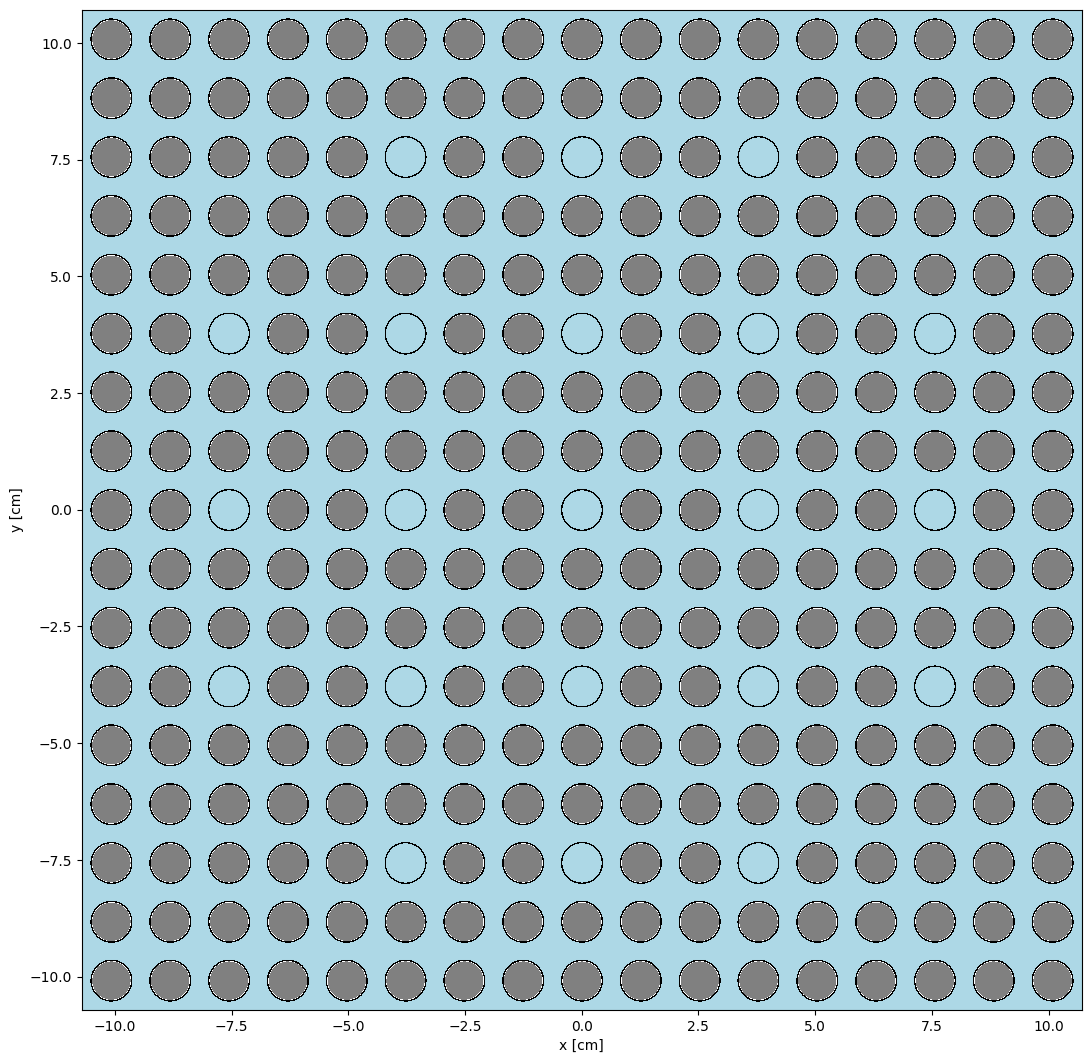

In [5]:
#Visual of reactor geometry. Colors are assigned to each material for better visualization.

colors = {
    fuel: 'grey',
    clad: 'black',
    coolant: 'lightblue'
}

geometry.plot(
    basis='xy',
    origin=(0, 0, 0),
    width=(17*1.26, 17*1.26),
    pixels=(1000, 1000),
    color_by='material',
    colors=colors
)

plt.show()

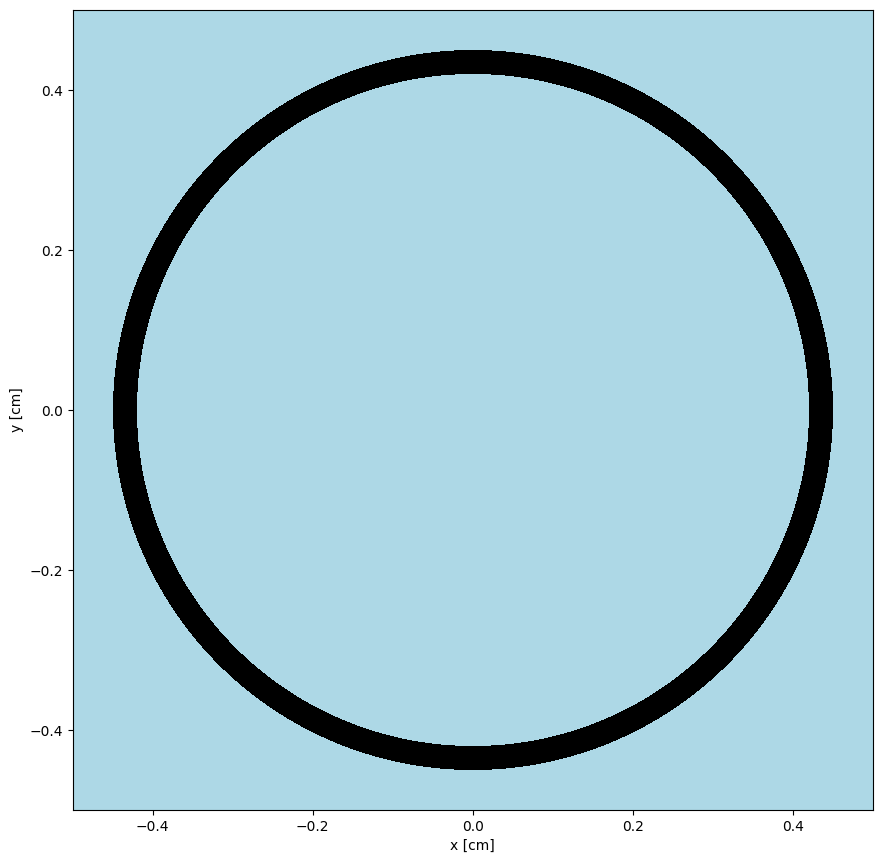

In [6]:
#visual of reactor geometry zoomed in to show the tube
geometry.plot(
    basis='xy',
    origin=(0, 0, 0),
    width=(1.0, 1.0),
    pixels=(800, 800),
    color_by='material',
    colors=colors
)

plt.show()

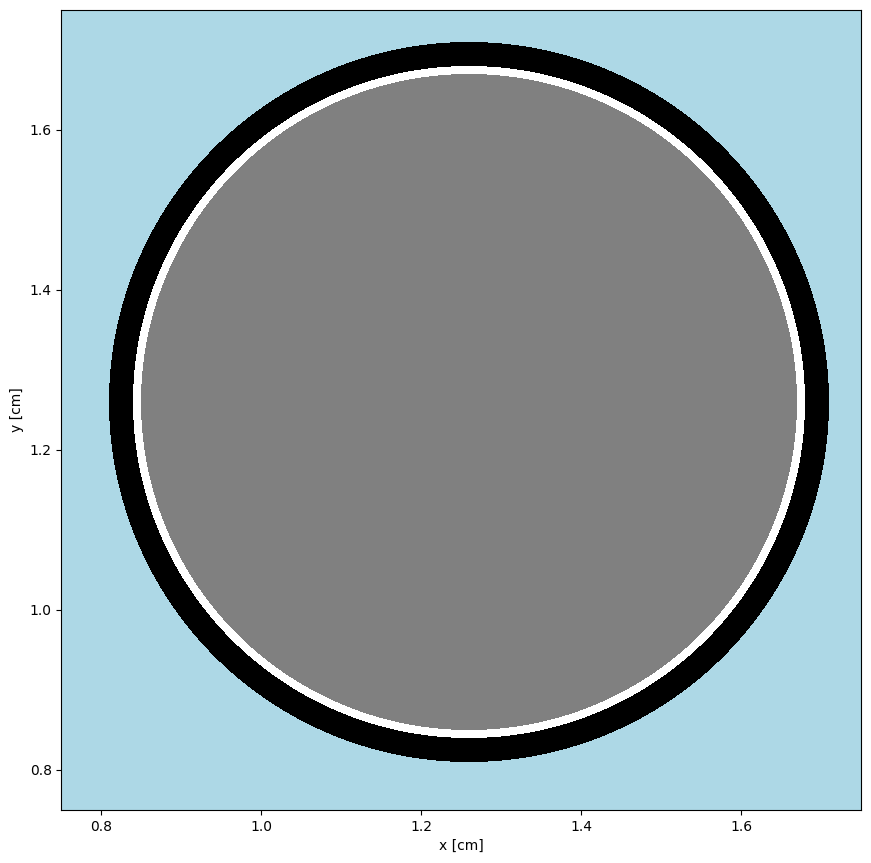

In [7]:
#visual of reactor geometry zoomed in to show the pin cell
geometry.plot(
    basis='xy',
    origin=(1.25, 1.25, 1),
    width=(1.0, 1.0),
    pixels=(800, 800),
    color_by='material',
    colors=colors
)

plt.show()

In [8]:
#simulation setting
width = 17 * 1.26

settings = openmc.Settings()
settings.run_mode = 'eigenvalue'
settings.batches = 150
settings.inactive = 30
settings.particles = 20000

source = openmc.IndependentSource(
    space=openmc.stats.Box(
        (-width/2, -width/2, -1),
        ( width/2,  width/2,  1),
        only_fissionable=True
    )
)
settings.source = source

/openmc_venv/lib/python3.12/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


In [9]:
#creating the model of the reactor

materials = openmc.Materials([fuel, clad, coolant])
model = openmc.Model(
    geometry=geometry,
    materials=materials,
    settings=settings
)

In [10]:
#check if model works
statepoint_file = model.run()




                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [11]:
#finding the keff of the reactor
sp = openmc.StatePoint(statepoint_file)
print(sp.keff)

1.4102+/-0.0006


#### Finding $k_{eff}$

In the following the optimal pitch for the assembly is determined by maximizing $k_{eff}$. 

Parameters used to perform a seep of an array of different pitch values:
- No of Particles: 
- No of Batches: 150
- Inactive: 30
- pitches range [1,2]

In [12]:
#reflective boundary prevent neutrons from leaving assembly,therefore k_inf=max(k_eff). Find max(½k_eff) by varying the pitch of the assembly.
import tempfile

def find_keff(pitches,geometry,materials,settings):
    keffs = []
    unc =  []
    for pitch in pitches:
        fuel_pin = make_pin(fuel, coolant, clad, pitch=pitch)
        guide_tube = make_tube(clad, coolant, pitch=pitch)
        geometry = make_assembly(fuel_pin, guide_tube, pitch=pitch, size=17)
        settings_sweep = settings #copy the settings to modify for each run
        settings_sweep.particles = 5000
        settings_sweep.batches = 150
        settings_sweep.inactive = 30
        model = openmc.Model(
            geometry=geometry,
            materials=materials,
            settings=settings_sweep
        )
        with tempfile.TemporaryDirectory(prefix='openmc_exp2_') as run_dir:
            output = model.run(cwd=run_dir)
            with openmc.StatePoint(output) as sp_local:
                k_val = sp_local.keff.nominal_value
                unc_val = sp_local.keff.std_dev
            keffs.append(k_val)
            unc.append(unc_val)
    return keffs, unc
    
    



In [13]:
pitches =  np.arange(1.0,2 ,0.02)
keffs, uncertainties = find_keff(pitches, geometry, materials, settings)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

Optimal pitch: 1.62 cm
Maximum k_eff: 1.46751


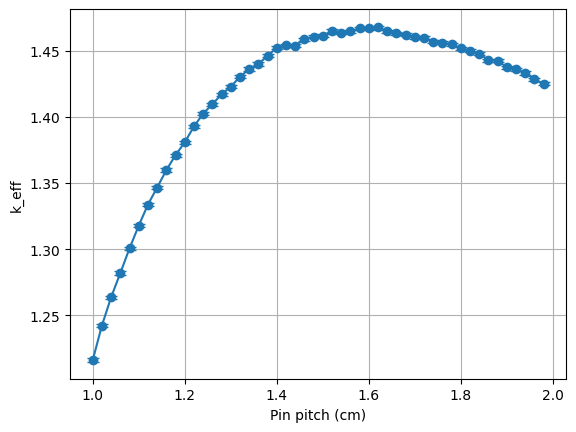

In [14]:
best_index = np.argmax(keffs)

best_pitch = pitches[best_index]
best_keff = keffs[best_index]

print(f'Optimal pitch: {best_pitch:.2f} cm')
print(f'Maximum k_eff: {best_keff:.5f}')

plt.errorbar(
    pitches,
    keffs,
    yerr=uncertainties,
    marker='o',
    capsize=4
)

plt.xlabel('Pin pitch (cm)')
plt.ylabel('k_eff')
plt.grid(True)
plt.show()

#### Boron Concentration 

The model is created using the pitch determined above. In the following the critical boron content is found. 

In [15]:
#Adding boron to coolant 
def make_coolant(bppm):
    coolant = material(
        'water',
        density=0.74,
        temperature=None,
        nuclides={
            'H1': 2.0,
            'O16': 1.0,
        })
    if bppm > 0:
        coolant.add_element('B', bppm * 1e-6)
    coolant.add_s_alpha_beta('c_H_in_H2O')
    return coolant

def model_with_boron(bppm):
    coolant = make_coolant(bppm)
    fuel_pin = make_pin(fuel, coolant, clad, pitch=best_pitch)
    guide_tube = make_tube(clad, coolant, pitch=best_pitch)
    geometry = make_assembly(fuel_pin, guide_tube, pitch=best_pitch)
    settings_sweep = openmc.Settings()
    settings_sweep.run_mode = 'eigenvalue'
    settings_sweep.particles = 5000
    settings_sweep.batches = 150
    settings_sweep.inactive = 30
    model = openmc.Model(
        geometry=geometry,
        materials=openmc.Materials([fuel, clad, coolant]),
        settings=settings_sweep
    )
    return model



In [16]:
ppms = [0,1000,2000,3500,4000] #searching for the interval of boron ppm that brings k_eff below 1.0

for ppm in ppms:
    model = model_with_boron(ppm)
    with tempfile.TemporaryDirectory(prefix='openmc_exp2_') as run_dir:
        output = model.run(cwd=run_dir)
        with openmc.StatePoint(output) as sp_local:
            k_val = sp_local.keff.nominal_value
        print(f'Boron ppm: {ppm}, k_eff: {k_val:.5f}')

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [17]:
bracket = [1000.,3500.]
os.system('rm *h5')
crit_ppm, guesses, keffs = openmc.search_for_keff(model_with_boron, target=1.2, bracket=bracket,
                                                  tol=1e-2, print_iterations=True)

print('Critical Boron Concentration: {:4.0f} ppm'.format(crit_ppm))

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

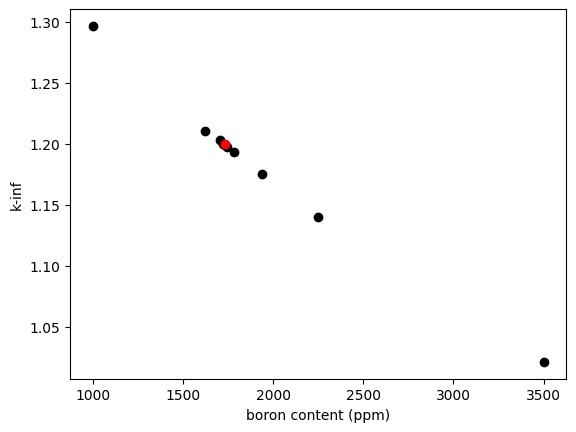

In [18]:
plt.figure()
for g,k in zip(guesses,keffs):
    plt.scatter(g,k.nominal_value,color='k')
plt.xlabel('boron content (ppm)')
plt.ylabel('k-inf')
plt.scatter(crit_ppm,1.2,color='r')
plt.show()

#### Burnup 

- depletion without poison
- depletion with fixed poison 
- depletion with variable poison 

earlier we found optimal pitch = 1.62, and boron content ppm = 1732. 

In [ ]:
def run_depletion(model, timesteps, power, #before depletion restart kernel to avoid conflicts with previous runs (Material ID errors)
                diff_mats=False, 
                time_units='d',
                result_file = 'depletion_results.h5'):
    
    # try:
    #     openmc.lib.finalize() #somehow initially fixed the ID error, but then didn't work for subsequent runs. Gap material turned out to be the issue. Leaving this here to log attempts to fix the issue for future reference.
    # except:
    #     pass
    
    model.export_to_xml()

    
    print("MATERIALS IN MODEL:") #checking materials in model to make sure all materials are included and depletable materials are correctly identified before depletion run
    for mat in model.materials:
        print(
            f"id={mat.id}, "
            f"name={mat.name}, "
            f"depletable={mat.depletable}"
        )
    
    operator = openmc.deplete.CoupledOperator(
        model,
        chain_file='/root/RFP/LectureFigures/chain_endfb71_pwr.xml',
        diff_burnable_mats=diff_mats
    )
    integrator = openmc.deplete.CECMIntegrator(
        operator,
        timesteps,
        power=power,
        timestep_units=time_units
    )

    integrator.integrate(path=result_file)

    results = openmc.deplete.Results(result_file)
    
    
    return results

#### Initial Test of model PWR without poison

In [4]:
mode = 'depletion'
pitch = 1.62
power = 1.8e7   # 18 MW

In [ ]:
timesteps = [5, 5, 10, 10, 20, 20]   # days
power = 1.0e6   # W
pwr = build_model(mode= mode, pitch=pitch)

#pwr_result =run_depletion(pwr, timesteps, power)



/openmc_venv/lib/python3.12/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


In [ ]:
pwr_result = openmc.deplete.Results('depletion_results.h5')


for step in range(len(pwr_result)):
    print(f'Timestep {step}')
    materials = pwr_result.export_to_materials(step)
    for mat in materials:
        print(mat.id, mat.name)
    

Timestep 0
1 coolant
2 fuel
3 clad
Timestep 1
1 coolant
2 fuel
3 clad
Timestep 2
1 coolant
2 fuel
3 clad
Timestep 3
1 coolant
2 fuel
3 clad
Timestep 4
1 coolant
2 fuel
3 clad
Timestep 5
1 coolant
2 fuel
3 clad
Timestep 6
1 coolant
2 fuel
3 clad


/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=1.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=2.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=3.
  warn(msg, IDWarning)


(array([      0.,  432000.,  864000., 1728000., 2592000., 4320000.,
        6048000.]),
 array([1.30642984e+25, 1.30481045e+25, 1.30319207e+25, 1.29996253e+25,
        1.29674118e+25, 1.29032253e+25, 1.28393721e+25]))

In [61]:
time, concentration = pwr_result.get_atoms(mat='2', nuc='U235', time_units='d')
print(f'Time (days): {time}')
print(f'U235 concentration (atoms/b-cm): {concentration}')

Time (days): [ 0.  5. 10. 20. 30. 50. 70.]
U235 concentration (atoms/b-cm): [1.30642984e+25 1.30481045e+25 1.30319207e+25 1.29996253e+25
 1.29674118e+25 1.29032253e+25 1.28393721e+25]


In [69]:
def plot_nuclides(results, material_id, nuclides):
    
    for nuc in nuclides:
        time, concentration = results.get_atoms(mat=material_id, nuc=nuc, nuc_units='atom/cm3', time_units='d')
        plt.plot(time, concentration, label=nuc)

    plt.xlabel('Time [days]')
    plt.ylabel('concentration [atom/cm³]')
    plt.title(f'Fuel depletion PWR, without poison')
    plt.yscale('log')
    plt.legend()
    plt.grid(True)

    plt.show()

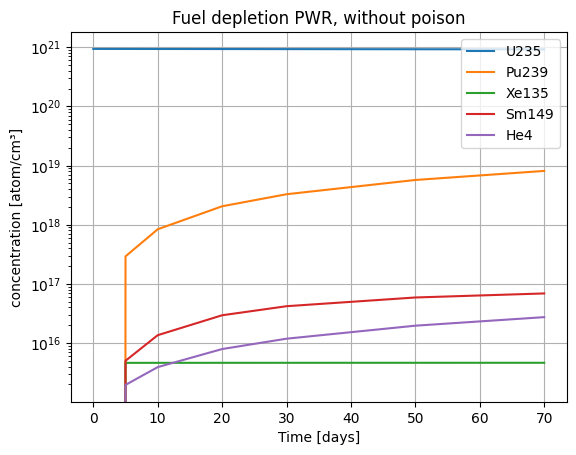

In [70]:
nuclides_to_plot = ['U235', 'Pu239', 'Xe135', 'Sm149', 'He4']
fuel_id = '2'
plot_nuclides(pwr_result, fuel_id, nuclides_to_plot)

##### Depletion Boron

In [5]:
# timesteps = [0.25]   # days 
timesteps = [0.25, 1, 5, 10, 20, 30] #deleted the result from the first depletion run with a lot of time steps, by accident. doing it again with fewer because of time limits. 
# timesteps = [
#     0.25, 0.25,
#     0.5, 0.5,
#     1, 1, 1,
#     2, 2, 2,
#     5, 5, 5,
#     10, 10,
#     20, 20,
#     30, 30
# ] # days 0 + 0.25 + 0.25 + 0.5 + 0.5 + 1 + 1 + 1 + 2 + 2 + 2 + 5 + 5 + 5 + 10 + 10 + 20 + 20 + 30 + 30 = 120 days
file = 'boron_depletion_results.h5'
boron_ppm = 1732 
pwr_boron = build_model(mode= mode, boron_ppms=boron_ppm, pitch=pitch)


/openmc_venv/lib/python3.12/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


In [6]:
boron_depletion_result = run_depletion(pwr_boron, timesteps, power, diff_mats=False, result_file=file)

MATERIALS IN MODEL:
id=2, name=fuel, depletable=True
id=3, name=clad, depletable=False
id=1, name=coolant, depletable=True
id=4, name=gap, depletable=False
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
        

 Reading Nb95 from /root/jeff-3.3-hdf5/Nb95.h5
 Reading Mo92 from /root/jeff-3.3-hdf5/Mo92.h5
 Reading Mo93 from /root/jeff-3.3-hdf5/Mo93.h5
 Reading Mo94 from /root/jeff-3.3-hdf5/Mo94.h5
 Reading Mo95 from /root/jeff-3.3-hdf5/Mo95.h5
 Reading Mo96 from /root/jeff-3.3-hdf5/Mo96.h5
 Reading Mo97 from /root/jeff-3.3-hdf5/Mo97.h5
 Reading Mo98 from /root/jeff-3.3-hdf5/Mo98.h5
 Reading Mo99 from /root/jeff-3.3-hdf5/Mo99.h5
 Reading Mo100 from /root/jeff-3.3-hdf5/Mo100.h5
 Reading Tc96 from /root/jeff-3.3-hdf5/Tc96.h5
 Reading Tc97 from /root/jeff-3.3-hdf5/Tc97.h5


          1200K
          2500K


 Reading Tc98 from /root/jeff-3.3-hdf5/Tc98.h5
 Reading Tc99 from /root/jeff-3.3-hdf5/Tc99.h5
 Reading Ru96 from /root/jeff-3.3-hdf5/Ru96.h5
 Reading Ru97 from /root/jeff-3.3-hdf5/Ru97.h5
 Reading Ru98 from /root/jeff-3.3-hdf5/Ru98.h5
 Reading Ru99 from /root/jeff-3.3-hdf5/Ru99.h5
 Reading Ru100 from /root/jeff-3.3-hdf5/Ru100.h5
 Reading Ru101 from /root/jeff-3.3-hdf5/Ru101.h5
 Reading Ru102 from /root/jeff-3.3-hdf5/Ru102.h5
 Reading Ru103 from /root/jeff-3.3-hdf5/Ru103.h5
 Reading Ru104 from /root/jeff-3.3-hdf5/Ru104.h5
 Reading Ru105 from /root/jeff-3.3-hdf5/Ru105.h5
 Reading Ru106 from /root/jeff-3.3-hdf5/Ru106.h5
 Reading Rh99 from /root/jeff-3.3-hdf5/Rh99.h5
 Reading Rh101 from /root/jeff-3.3-hdf5/Rh101.h5
 Reading Rh102 from /root/jeff-3.3-hdf5/Rh102.h5
 Reading Rh103 from /root/jeff-3.3-hdf5/Rh103.h5
 Reading Rh104 from /root/jeff-3.3-hdf5/Rh104.h5
 Reading Rh105 from /root/jeff-3.3-hdf5/Rh105.h5
 Reading Pd102 from /root/jeff-3.3-hdf5/Pd102.h5
 Reading Pd103 from /root/jeff-3.3

          1200K
          2500K


...

 Reading Pm151 from /root/jeff-3.3-hdf5/Pm151.h5
 Reading Sm144 from /root/jeff-3.3-hdf5/Sm144.h5
 Reading Sm145 from /root/jeff-3.3-hdf5/Sm145.h5
 Reading Sm146 from /root/jeff-3.3-hdf5/Sm146.h5
 Reading Sm147 from /root/jeff-3.3-hdf5/Sm147.h5
 Reading Sm148 from /root/jeff-3.3-hdf5/Sm148.h5
 Reading Sm149 from /root/jeff-3.3-hdf5/Sm149.h5
 Reading Sm150 from /root/jeff-3.3-hdf5/Sm150.h5
 Reading Sm151 from /root/jeff-3.3-hdf5/Sm151.h5
 Reading Sm152 from /root/jeff-3.3-hdf5/Sm152.h5
 Reading Sm153 from /root/jeff-3.3-hdf5/Sm153.h5
 Reading Sm154 from /root/jeff-3.3-hdf5/Sm154.h5
 Reading Eu151 from /root/jeff-3.3-hdf5/Eu151.h5
 Reading Eu152 from /root/jeff-3.3-hdf5/Eu152.h5
 Reading Eu152_m1 from /root/jeff-3.3-hdf5/Eu152_m1.h5
 Reading Eu153 from /root/jeff-3.3-hdf5/Eu153.h5
 Reading Eu154 from /root/jeff-3.3-hdf5/Eu154.h5
 Reading Eu155 from /root/jeff-3.3-hdf5/Eu155.h5
 Reading Eu156 from /root/jeff-3.3-hdf5/Eu156.h5
 Reading Eu157 from /root/jeff-3.3-hdf5/Eu157.h5
 Reading Gd148

          1200K


 Reading Pu239 from /root/jeff-3.3-hdf5/Pu239.h5
 Reading Pu240 from /root/jeff-3.3-hdf5/Pu240.h5
 Reading Pu241 from /root/jeff-3.3-hdf5/Pu241.h5
 Reading Pu242 from /root/jeff-3.3-hdf5/Pu242.h5
 Reading Pu243 from /root/jeff-3.3-hdf5/Pu243.h5
 Reading Pu244 from /root/jeff-3.3-hdf5/Pu244.h5
 Reading Pu246 from /root/jeff-3.3-hdf5/Pu246.h5
 Reading Am241 from /root/jeff-3.3-hdf5/Am241.h5
 Reading Am242 from /root/jeff-3.3-hdf5/Am242.h5
 Reading Am242_m1 from /root/jeff-3.3-hdf5/Am242_m1.h5
 Reading Am243 from /root/jeff-3.3-hdf5/Am243.h5
 Reading Am244 from /root/jeff-3.3-hdf5/Am244.h5
 Reading Am244_m1 from /root/jeff-3.3-hdf5/Am244_m1.h5
 Reading Cm240 from /root/jeff-3.3-hdf5/Cm240.h5
 Reading Cm241 from /root/jeff-3.3-hdf5/Cm241.h5
 Reading Cm242 from /root/jeff-3.3-hdf5/Cm242.h5
 Reading Cm243 from /root/jeff-3.3-hdf5/Cm243.h5
 Reading Cm244 from /root/jeff-3.3-hdf5/Cm244.h5
 Reading Cm245 from /root/jeff-3.3-hdf5/Cm245.h5
 Reading Cm246 from /root/jeff-3.3-hdf5/Cm246.h5
 Reading

          1200K


 Maximum neutron transport energy: 20000000 eV for H1
 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    1.19210
        2/1    1.20116
        3/1    1.18794
        4/1    1.21154
        5/1    1.19587
        6/1    1.21094
        7/1    1.18638
        8/1    1.19842
        9/1    1.20465
       10/1    1.21127
       11/1    1.20201
       12/1    1.19678
       13/1    1.20998
       14/1    1.19954
       15/1    1.19337
       16/1    1.20703
       17/1    1.19107
       18/1    1.20743
       19/1    1.18738
       20/1    1.19000
       21/1    1.19465
       22/1    1.19143
       23/1    1.19647
       24/1    1.19645
       25/1    1.21332
       26/1    1.19078
       27/1    1.19544    1.19311 +/- 0.00233
       28/1    1.19868    1.19497 +/- 0.00229
       29/1    1.19469    1.19490 +/- 0.00162
       30/1

#### Gadolinium 

Finding optimal gad frac

In [9]:
fracs = [0.01, 0.02, 0.04, 0.05, 0.06] #searching for the interval of boron ppm that brings k_eff below 1.0

for frac in fracs:
    model = build_model(mode='sweep', gad_frac=frac, pitch=pitch)
    with tempfile.TemporaryDirectory(prefix='openmc_exp2_') as run_dir:
        output = model.run(cwd=run_dir)
        with openmc.StatePoint(output) as sp_local:
            k_val = sp_local.keff.nominal_value
        print(f'gad_frac: {frac}, k_eff: {k_val:.5f}')

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

/openmc_venv/lib/python3.12/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

/openmc_venv/lib/python3.12/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


 Reading U235 from /root/jeff-3.3-hdf5/U235.h5
 Reading U238 from /root/jeff-3.3-hdf5/U238.h5
 Reading Zr90 from /root/jeff-3.3-hdf5/Zr90.h5
 Reading Zr91 from /root/jeff-3.3-hdf5/Zr91.h5
 Reading Zr92 from /root/jeff-3.3-hdf5/Zr92.h5
 Reading Zr94 from /root/jeff-3.3-hdf5/Zr94.h5
 Reading Zr96 from /root/jeff-3.3-hdf5/Zr96.h5
 Reading He4 from /root/jeff-3.3-hdf5/He4.h5
 Reading Gd155 from /root/jeff-3.3-hdf5/Gd155.h5
 Reading c_H_in_H2O from /root/jeff-3.3-hdf5/c_H_in_H2O.h5
 Minimum neutron data temperature: 294 K
 Maximum neutron data temperature: 1200 K
 Preparing distributed cell instances...
 Writing summary.h5 file...
 Maximum neutron transport energy: 20000000 eV for H1
 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    1.34489
        2/1    1.36975
        3/1    1.35456
        4/1    1.36200
        5/1    1.3992

/openmc_venv/lib/python3.12/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


 Reading U238 from /root/jeff-3.3-hdf5/U238.h5
 Reading Zr90 from /root/jeff-3.3-hdf5/Zr90.h5
 Reading Zr91 from /root/jeff-3.3-hdf5/Zr91.h5
 Reading Zr92 from /root/jeff-3.3-hdf5/Zr92.h5
 Reading Zr94 from /root/jeff-3.3-hdf5/Zr94.h5
 Reading Zr96 from /root/jeff-3.3-hdf5/Zr96.h5
 Reading He4 from /root/jeff-3.3-hdf5/He4.h5
 Reading Gd155 from /root/jeff-3.3-hdf5/Gd155.h5
 Reading c_H_in_H2O from /root/jeff-3.3-hdf5/c_H_in_H2O.h5
 Minimum neutron data temperature: 294 K
 Maximum neutron data temperature: 1200 K
 Preparing distributed cell instances...
 Writing summary.h5 file...
 Maximum neutron transport energy: 20000000 eV for H1
 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    1.34662
        2/1    1.39469
        3/1    1.39403
        4/1    1.34045
        5/1    1.36979
        6/1    1.38212
        7/1    1.36327

/openmc_venv/lib/python3.12/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


 Reading U238 from /root/jeff-3.3-hdf5/U238.h5
 Reading Zr90 from /root/jeff-3.3-hdf5/Zr90.h5
 Reading Zr91 from /root/jeff-3.3-hdf5/Zr91.h5
 Reading Zr92 from /root/jeff-3.3-hdf5/Zr92.h5
 Reading Zr94 from /root/jeff-3.3-hdf5/Zr94.h5
 Reading Zr96 from /root/jeff-3.3-hdf5/Zr96.h5
 Reading He4 from /root/jeff-3.3-hdf5/He4.h5
 Reading Gd155 from /root/jeff-3.3-hdf5/Gd155.h5
 Reading c_H_in_H2O from /root/jeff-3.3-hdf5/c_H_in_H2O.h5
 Minimum neutron data temperature: 294 K
 Maximum neutron data temperature: 1200 K
 Preparing distributed cell instances...
 Writing summary.h5 file...
 Maximum neutron transport energy: 20000000 eV for H1
 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    1.34216
        2/1    1.37833
        3/1    1.39250
        4/1    1.35076
        5/1    1.34967
        6/1    1.35828
        7/1    1.36394

In [10]:
timesteps = [0.25, 1, 5, 10, 20, 30]

timesteps_test =[0.25]
gad_frac = 0.06
file = 'gad_depletion_results.h5'

pwr_gad = build_model(mode= mode, gad_frac=gad_frac, pitch=pitch)

/openmc_venv/lib/python3.12/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


In [11]:
gad_depletion_result = run_depletion(pwr_gad, timesteps, power, diff_mats=False, result_file=file)

MATERIALS IN MODEL:
id=27, name=fuel, depletable=True
id=28, name=clad, depletable=False
id=26, name=coolant, depletable=False
id=29, name=gap, depletable=False
id=30, name=gad_fuel, depletable=True
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                #############

 Reading Nb95 from /root/jeff-3.3-hdf5/Nb95.h5
 Reading Mo92 from /root/jeff-3.3-hdf5/Mo92.h5
 Reading Mo93 from /root/jeff-3.3-hdf5/Mo93.h5
 Reading Mo94 from /root/jeff-3.3-hdf5/Mo94.h5
 Reading Mo95 from /root/jeff-3.3-hdf5/Mo95.h5
 Reading Mo96 from /root/jeff-3.3-hdf5/Mo96.h5
 Reading Mo97 from /root/jeff-3.3-hdf5/Mo97.h5
 Reading Mo98 from /root/jeff-3.3-hdf5/Mo98.h5
 Reading Mo99 from /root/jeff-3.3-hdf5/Mo99.h5
 Reading Mo100 from /root/jeff-3.3-hdf5/Mo100.h5
 Reading Tc96 from /root/jeff-3.3-hdf5/Tc96.h5
 Reading Tc97 from /root/jeff-3.3-hdf5/Tc97.h5


          1200K
          2500K


 Reading Tc98 from /root/jeff-3.3-hdf5/Tc98.h5
 Reading Tc99 from /root/jeff-3.3-hdf5/Tc99.h5
 Reading Ru96 from /root/jeff-3.3-hdf5/Ru96.h5
 Reading Ru97 from /root/jeff-3.3-hdf5/Ru97.h5
 Reading Ru98 from /root/jeff-3.3-hdf5/Ru98.h5
 Reading Ru99 from /root/jeff-3.3-hdf5/Ru99.h5
 Reading Ru100 from /root/jeff-3.3-hdf5/Ru100.h5
 Reading Ru101 from /root/jeff-3.3-hdf5/Ru101.h5
 Reading Ru102 from /root/jeff-3.3-hdf5/Ru102.h5
 Reading Ru103 from /root/jeff-3.3-hdf5/Ru103.h5
 Reading Ru104 from /root/jeff-3.3-hdf5/Ru104.h5
 Reading Ru105 from /root/jeff-3.3-hdf5/Ru105.h5
 Reading Ru106 from /root/jeff-3.3-hdf5/Ru106.h5
 Reading Rh99 from /root/jeff-3.3-hdf5/Rh99.h5
 Reading Rh101 from /root/jeff-3.3-hdf5/Rh101.h5
 Reading Rh102 from /root/jeff-3.3-hdf5/Rh102.h5
 Reading Rh103 from /root/jeff-3.3-hdf5/Rh103.h5
 Reading Rh104 from /root/jeff-3.3-hdf5/Rh104.h5
 Reading Rh105 from /root/jeff-3.3-hdf5/Rh105.h5
 Reading Pd102 from /root/jeff-3.3-hdf5/Pd102.h5
 Reading Pd103 from /root/jeff-3.3

          1200K
          2500K


...

 Reading Pm149 from /root/jeff-3.3-hdf5/Pm149.h5
 Reading Pm151 from /root/jeff-3.3-hdf5/Pm151.h5
 Reading Sm144 from /root/jeff-3.3-hdf5/Sm144.h5
 Reading Sm145 from /root/jeff-3.3-hdf5/Sm145.h5
 Reading Sm146 from /root/jeff-3.3-hdf5/Sm146.h5
 Reading Sm147 from /root/jeff-3.3-hdf5/Sm147.h5
 Reading Sm148 from /root/jeff-3.3-hdf5/Sm148.h5
 Reading Sm149 from /root/jeff-3.3-hdf5/Sm149.h5
 Reading Sm150 from /root/jeff-3.3-hdf5/Sm150.h5
 Reading Sm151 from /root/jeff-3.3-hdf5/Sm151.h5
 Reading Sm152 from /root/jeff-3.3-hdf5/Sm152.h5
 Reading Sm153 from /root/jeff-3.3-hdf5/Sm153.h5
 Reading Sm154 from /root/jeff-3.3-hdf5/Sm154.h5
 Reading Eu151 from /root/jeff-3.3-hdf5/Eu151.h5
 Reading Eu152 from /root/jeff-3.3-hdf5/Eu152.h5
 Reading Eu152_m1 from /root/jeff-3.3-hdf5/Eu152_m1.h5
 Reading Eu153 from /root/jeff-3.3-hdf5/Eu153.h5
 Reading Eu154 from /root/jeff-3.3-hdf5/Eu154.h5
 Reading Eu155 from /root/jeff-3.3-hdf5/Eu155.h5
 Reading Eu156 from /root/jeff-3.3-hdf5/Eu156.h5
 Reading Eu157

          1200K


 Reading Pu236 from /root/jeff-3.3-hdf5/Pu236.h5
 Reading Pu237 from /root/jeff-3.3-hdf5/Pu237.h5
 Reading Pu238 from /root/jeff-3.3-hdf5/Pu238.h5
 Reading Pu239 from /root/jeff-3.3-hdf5/Pu239.h5
 Reading Pu240 from /root/jeff-3.3-hdf5/Pu240.h5
 Reading Pu241 from /root/jeff-3.3-hdf5/Pu241.h5
 Reading Pu242 from /root/jeff-3.3-hdf5/Pu242.h5
 Reading Pu243 from /root/jeff-3.3-hdf5/Pu243.h5
 Reading Pu244 from /root/jeff-3.3-hdf5/Pu244.h5
 Reading Pu246 from /root/jeff-3.3-hdf5/Pu246.h5
 Reading Am241 from /root/jeff-3.3-hdf5/Am241.h5
 Reading Am242 from /root/jeff-3.3-hdf5/Am242.h5
 Reading Am242_m1 from /root/jeff-3.3-hdf5/Am242_m1.h5
 Reading Am243 from /root/jeff-3.3-hdf5/Am243.h5
 Reading Am244 from /root/jeff-3.3-hdf5/Am244.h5
 Reading Am244_m1 from /root/jeff-3.3-hdf5/Am244_m1.h5
 Reading Cm240 from /root/jeff-3.3-hdf5/Cm240.h5
 Reading Cm241 from /root/jeff-3.3-hdf5/Cm241.h5
 Reading Cm242 from /root/jeff-3.3-hdf5/Cm242.h5
 Reading Cm243 from /root/jeff-3.3-hdf5/Cm243.h5
 Reading

          1200K


 Reading Es255 from /root/jeff-3.3-hdf5/Es255.h5
 Reading Fm255 from /root/jeff-3.3-hdf5/Fm255.h5
 Maximum neutron transport energy: 20000000 eV for H1
 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    1.35031
        2/1    1.34109
        3/1    1.37179
        4/1    1.36853
        5/1    1.35585
        6/1    1.34017
        7/1    1.35436
        8/1    1.37162
        9/1    1.37619
       10/1    1.39568
       11/1    1.38504
       12/1    1.37471
       13/1    1.38200
       14/1    1.36190
       15/1    1.37098
       16/1    1.37729
       17/1    1.37885
       18/1    1.38514
       19/1    1.36466
       20/1    1.36616
       21/1    1.36100
       22/1    1.36628
       23/1    1.36634
       24/1    1.36969
       25/1    1.36374
       26/1    1.38723
       27/1    1.35023    1.36873 +/- 0.01850
     

#### Neutron Flux 

calculating the neutron flux for 
- PWR no poison
- PWR with Boron
- PWR with Gadolinium 

In [3]:
def neutron_flux(model):
    sp_file = model.run()
    sp = openmc.StatePoint(sp_file)
    flux = sp.get_tally(name='flux')
    flux_data = flux.mean.reshape((200, 200))
    return flux_data    

def plot_flux(flux_data, title):
    plt.figure(figsize=(8,8))
    plt.imshow(flux_data, origin='lower')
    plt.colorbar(label='Neutron Flux')
    plt.title(title)  
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

#### PWR No Poison

/openmc_venv/lib/python3.12/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

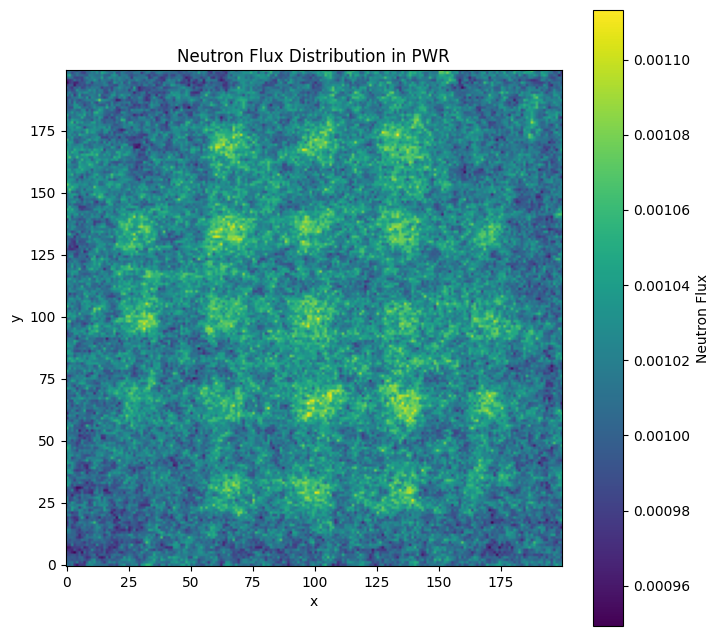

In [5]:
pwr_flux_model = build_model(mode='sweep', pitch=pitch)
pwr_flux = neutron_flux(pwr_flux_model)
plot_flux(pwr_flux, title='Neutron Flux Distribution in PWR')

##### Neutron flux Boron 

/openmc_venv/lib/python3.12/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

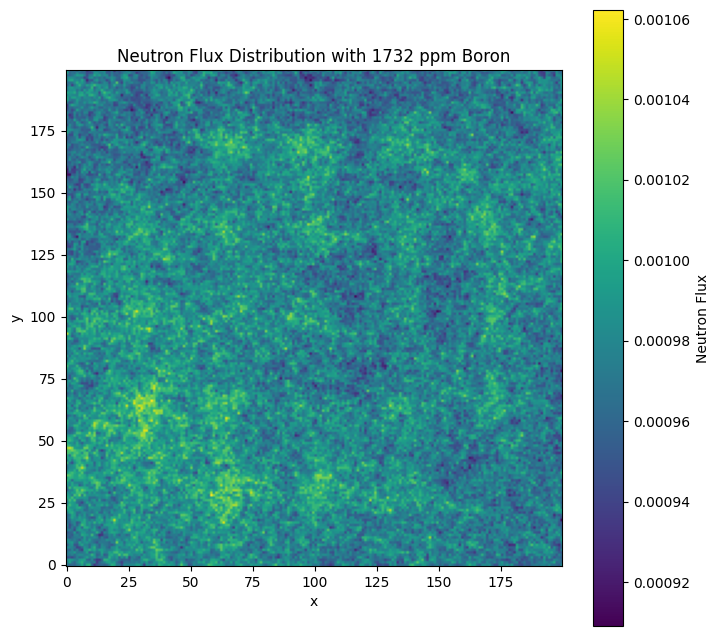

In [6]:
boron_ppm = 1732 
boron_flux_model = build_model(mode='sweep', boron_ppms = boron_ppm, pitch=pitch)
boron_flux = neutron_flux(boron_flux_model)
plot_flux(boron_flux, title=f'Neutron Flux Distribution with {boron_ppm} ppm Boron')

##### Neutron Flux Gad 

/openmc_venv/lib/python3.12/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

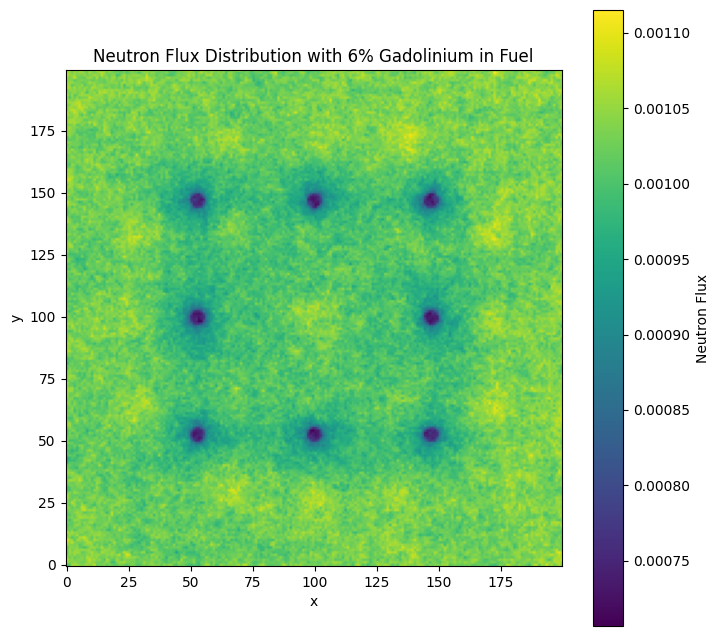

In [7]:
gad_frac = 0.06 
ga_flux_model = build_model(mode='sweep', gad_frac = gad_frac, pitch=pitch)
ga_flux = neutron_flux(ga_flux_model)
plot_flux(ga_flux, title=f'Neutron Flux Distribution with {gad_frac*100:.0f}% Gadolinium in Fuel')


##### Xe Buildup Reaktor Shutdown

In [ ]:
# def build_model( # if flux works try this for the shutdown
#     mode='sweep',
#     boron_ppms=0,
#     gad_frac=0,
#     pitch=1.26,
#     assembly_size=17,
#     materials_override=None
# ):
# if materials_override is not None:
#     materials = materials_override
# else:
#     # create fresh materials normally

def shutdown_depletion(model, operation_time, shutdown_time, init_power, result_file):
    operation_result = run_depletion(model, operation_time, init_power, diff_mats=False, result_file='operation.h5')
    shutdown_materials = operation_result.export_to_materials(-1)
    model.materials = shutdown_materials
    model.export_to_xml()
    shutdown_result = run_depletion(model, shutdown_time, power=0, diff_mats=False, time_units='h', result_file=result_file)
    return shutdown_result

In [8]:
operation_steps = [1,1,1,1,1]

shutdown_steps = [0.1,0.1,0.5,1,2,4,8,12]

pwr_shutdown_model = build_model(mode='depletion', pitch=pitch)


/openmc_venv/lib/python3.12/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


In [9]:
shutdown_result = shutdown_depletion(pwr_shutdown_model, 
                                    operation_time=operation_steps, 
                                    shutdown_time=shutdown_steps,
                                    init_power=power,
                                    result_file='shutdown_results.h5')

MATERIALS IN MODEL:
id=2, name=fuel, depletable=True
id=3, name=clad, depletable=False
id=1, name=coolant, depletable=False
id=4, name=gap, depletable=False
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
       

 Reading Nb94_m1 from /root/jeff-3.3-hdf5/Nb94_m1.h5
 Reading Nb95 from /root/jeff-3.3-hdf5/Nb95.h5
 Reading Mo92 from /root/jeff-3.3-hdf5/Mo92.h5
 Reading Mo93 from /root/jeff-3.3-hdf5/Mo93.h5
 Reading Mo94 from /root/jeff-3.3-hdf5/Mo94.h5
 Reading Mo95 from /root/jeff-3.3-hdf5/Mo95.h5
 Reading Mo96 from /root/jeff-3.3-hdf5/Mo96.h5
 Reading Mo97 from /root/jeff-3.3-hdf5/Mo97.h5
 Reading Mo98 from /root/jeff-3.3-hdf5/Mo98.h5
 Reading Mo99 from /root/jeff-3.3-hdf5/Mo99.h5
 Reading Mo100 from /root/jeff-3.3-hdf5/Mo100.h5
 Reading Tc96 from /root/jeff-3.3-hdf5/Tc96.h5
 Reading Tc97 from /root/jeff-3.3-hdf5/Tc97.h5


          1200K
          2500K


 Reading Tc98 from /root/jeff-3.3-hdf5/Tc98.h5
 Reading Tc99 from /root/jeff-3.3-hdf5/Tc99.h5
 Reading Ru96 from /root/jeff-3.3-hdf5/Ru96.h5
 Reading Ru97 from /root/jeff-3.3-hdf5/Ru97.h5
 Reading Ru98 from /root/jeff-3.3-hdf5/Ru98.h5
 Reading Ru99 from /root/jeff-3.3-hdf5/Ru99.h5
 Reading Ru100 from /root/jeff-3.3-hdf5/Ru100.h5
 Reading Ru101 from /root/jeff-3.3-hdf5/Ru101.h5
 Reading Ru102 from /root/jeff-3.3-hdf5/Ru102.h5
 Reading Ru103 from /root/jeff-3.3-hdf5/Ru103.h5
 Reading Ru104 from /root/jeff-3.3-hdf5/Ru104.h5
 Reading Ru105 from /root/jeff-3.3-hdf5/Ru105.h5
 Reading Ru106 from /root/jeff-3.3-hdf5/Ru106.h5
 Reading Rh99 from /root/jeff-3.3-hdf5/Rh99.h5
 Reading Rh101 from /root/jeff-3.3-hdf5/Rh101.h5
 Reading Rh102 from /root/jeff-3.3-hdf5/Rh102.h5
 Reading Rh103 from /root/jeff-3.3-hdf5/Rh103.h5
 Reading Rh104 from /root/jeff-3.3-hdf5/Rh104.h5
 Reading Rh105 from /root/jeff-3.3-hdf5/Rh105.h5
 Reading Pd102 from /root/jeff-3.3-hdf5/Pd102.h5
 Reading Pd103 from /root/jeff-3.3

          1200K
          2500K


...

 Reading Pu236 from /root/jeff-3.3-hdf5/Pu236.h5
 Reading Pu237 from /root/jeff-3.3-hdf5/Pu237.h5
 Reading Pu238 from /root/jeff-3.3-hdf5/Pu238.h5
 Reading Pu239 from /root/jeff-3.3-hdf5/Pu239.h5
 Reading Pu240 from /root/jeff-3.3-hdf5/Pu240.h5
 Reading Pu241 from /root/jeff-3.3-hdf5/Pu241.h5
 Reading Pu242 from /root/jeff-3.3-hdf5/Pu242.h5
 Reading Pu243 from /root/jeff-3.3-hdf5/Pu243.h5
 Reading Pu244 from /root/jeff-3.3-hdf5/Pu244.h5
 Reading Pu246 from /root/jeff-3.3-hdf5/Pu246.h5
 Reading Am241 from /root/jeff-3.3-hdf5/Am241.h5
 Reading Am242 from /root/jeff-3.3-hdf5/Am242.h5
 Reading Am242_m1 from /root/jeff-3.3-hdf5/Am242_m1.h5
 Reading Am243 from /root/jeff-3.3-hdf5/Am243.h5
 Reading Am244 from /root/jeff-3.3-hdf5/Am244.h5
 Reading Am244_m1 from /root/jeff-3.3-hdf5/Am244_m1.h5
 Reading Cm240 from /root/jeff-3.3-hdf5/Cm240.h5
 Reading Cm241 from /root/jeff-3.3-hdf5/Cm241.h5
 Reading Cm242 from /root/jeff-3.3-hdf5/Cm242.h5
 Reading Cm243 from /root/jeff-3.3-hdf5/Cm243.h5
 Reading

          1200K


 Reading Si32 from /root/jeff-3.3-hdf5/Si32.h5
 Reading Ca48 from /root/jeff-3.3-hdf5/Ca48.h5
 Reading Ti44 from /root/jeff-3.3-hdf5/Ti44.h5
 Reading V48 from /root/jeff-3.3-hdf5/V48.h5
 Reading Mn52 from /root/jeff-3.3-hdf5/Mn52.h5
 Reading Mn53 from /root/jeff-3.3-hdf5/Mn53.h5
 Reading Fe54 from /root/jeff-3.3-hdf5/Fe54.h5
 Reading Fe60 from /root/jeff-3.3-hdf5/Fe60.h5
 Reading Co56 from /root/jeff-3.3-hdf5/Co56.h5
 Reading Co58_m1 from /root/jeff-3.3-hdf5/Co58_m1.h5
 Reading Co62_m1 from /root/jeff-3.3-hdf5/Co62_m1.h5
 Reading Ni56 from /root/jeff-3.3-hdf5/Ni56.h5
 Reading Yb173 from /root/jeff-3.3-hdf5/Yb173.h5
 Reading Yb174 from /root/jeff-3.3-hdf5/Yb174.h5
 Reading Yb175 from /root/jeff-3.3-hdf5/Yb175.h5
 Reading Yb176 from /root/jeff-3.3-hdf5/Yb176.h5
 Reading Lu173 from /root/jeff-3.3-hdf5/Lu173.h5
 Reading Lu174 from /root/jeff-3.3-hdf5/Lu174.h5
 Reading Lu175 from /root/jeff-3.3-hdf5/Lu175.h5
 Reading Lu176 from /root/jeff-3.3-hdf5/Lu176.h5
 Reading Lu177 from /root/jeff-3.3

/openmc_venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


[openmc.deplete] t=8640.0 s, dt=8640.0 s, source=0
 Creating state point openmc_simulation_n1.h5...
[openmc.deplete] t=17280.0 s, dt=43200.0 s, source=0
 Creating state point openmc_simulation_n2.h5...
[openmc.deplete] t=60480.0 s, dt=86400.0 s, source=0
 Creating state point openmc_simulation_n3.h5...
[openmc.deplete] t=146880.0 s, dt=172800.0 s, source=0
 Creating state point openmc_simulation_n4.h5...
[openmc.deplete] t=319680.0 s, dt=345600.0 s, source=0
 Creating state point openmc_simulation_n5.h5...
[openmc.deplete] t=665280.0 s, dt=691200.0 s, source=0
 Creating state point openmc_simulation_n6.h5...
[openmc.deplete] t=1356480.0 s, dt=1036800.0 s, source=0
 Creating state point openmc_simulation_n7.h5...
[openmc.deplete] t=2393280.0 (final operator evaluation)
 Creating state point openmc_simulation_n8.h5...
